# Importing python libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold

# Dataset details

In [2]:
crypto=pd.read_csv("Cryptocurrency_Transaction_Data.csv")

In [3]:
crypto.head() # Showing first few rows

,Transaction_ID,Sender_Address,Receiver_Address,Amount,Transaction_Fee,Timestamp,Block_ID,Mining_Pool,Currency,Transaction_Type,Transaction_Status,Gas_Price_Gwei
0,TX2QW62Q5XM17K,0xd377b9203ad74038664c08f658c0245632651f55,0x4a3370c0f0b83d519ddf50892d006f64d7425880,11.396181,0.000062,2025-03-30T23:32:40.589676Z,f4A4D894b9Ee166B3F75F4Fb,Ethermine,ETH,Transfer,Confirmed,50.0
1,TXQLO0O0OTW4LJ,0x82f88633d0181ac75ddf2a30e0536715323c36bb,0x7faeb5aa2b3c1d34bbe742dbf58a9405677983ce,9.504004,0.000043,2025-03-09T17:41:40.589676Z,9dDdFb5D8EfE8f162cadBd5a,Ethermine,ETH,Transfer,Confirmed,25.0
2,TXUQHLOGH29HUX,0x3df47b281761298334f39e351a37135e366e00bc,3cwt5fdejoeo52pjyayfwvyufulihttiqs,1.814056,0.000199,2025-05-10T22:33:40.589676Z,29da64FB8ba86DBfE3c9fFD6,BTC.TOP,BTC,Transfer,Confirmed,NaN
3,TXOUB0QDRACX9V,0x048ec0b0375c05d8232374bee7cbf9d962003916,367olmymnss867abmhfqdw9u2p4uxrcuer,4.759595,0.000704,2025-03-29T19:07:40.589676Z,81e422afbc4DE8bFbf0266E2,Poolin,BTC,Transfer,Confirmed,NaN
4,TXITZPHD2NENA7,0x5cd4d3cc6a2f410a350c0d3ad929ec1a2f4c32f5,0xe166fa006fd6b7d427d19e7e28c9338ab40cd273,12.333792,0.000273,2025-03-05T08:29:40.589676Z,C1B27A9583D7FB3Aa5A7e140,Ethermine,ETH,Transfer,Confirmed,50.0


In [4]:
crypto.info() #information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      50000 non-null  object 
 1   Sender_Address      50000 non-null  object 
 2   Receiver_Address    50000 non-null  object 
 3   Amount              50000 non-null  float64
 4   Transaction_Fee     50000 non-null  float64
 5   Timestamp           50000 non-null  object 
 6   Block_ID            50000 non-null  object 
 7   Mining_Pool         50000 non-null  object 
 8   Currency            50000 non-null  object 
 9   Transaction_Type    50000 non-null  object 
 10  Transaction_Status  50000 non-null  object 
 11  Gas_Price_Gwei      25012 non-null  float64
dtypes: float64(3), object(9)
memory usage: 4.6+ MB


# Determining null values and treatment

In [5]:
crypto.isnull().sum()

Transaction_ID            0
Sender_Address            0
Receiver_Address          0
Amount                    0
Transaction_Fee           0
Timestamp                 0
Block_ID                  0
Mining_Pool               0
Currency                  0
Transaction_Type          0
Transaction_Status        0
Gas_Price_Gwei        24988
dtype: int64

### Removing null values

In [6]:
eth_median = crypto.loc[crypto['Currency'] == 'ETH', 'Gas_Price_Gwei'].median()
crypto['Gas_Price_Gwei'] = np.where(
    crypto['Currency'] == 'ETH',
    crypto['Gas_Price_Gwei'].fillna(eth_median),
    crypto['Gas_Price_Gwei'].fillna(0))

In [7]:
crypto['Timestamp'] = pd.to_datetime(crypto['Timestamp'], errors='coerce') # data preprocessing

### Finding duplicate values

In [8]:
duplicates = crypto.duplicated(subset='Transaction_ID').sum()
print(f"Duplicate Transactions: {duplicates}")

Duplicate Transactions: 0


# Outlier handling

In [9]:
numeric_cols = ['Amount', 'Transaction_Fee', 'Gas_Price_Gwei']
crypto[numeric_cols].describe()  # Data description

,Amount,Transaction_Fee,Gas_Price_Gwei
count,50000.000000,50000.000000,50000.000000
mean,7.519087,0.000382,13.580300
std,4.321356,0.000257,16.403516
min,0.006032,0.000010,0.000000
25%,3.784158,0.000177,0.000000
50%,7.514979,0.000340,10.000000
75%,11.234608,0.000506,25.000000
max,14.999943,0.001000,50.000000


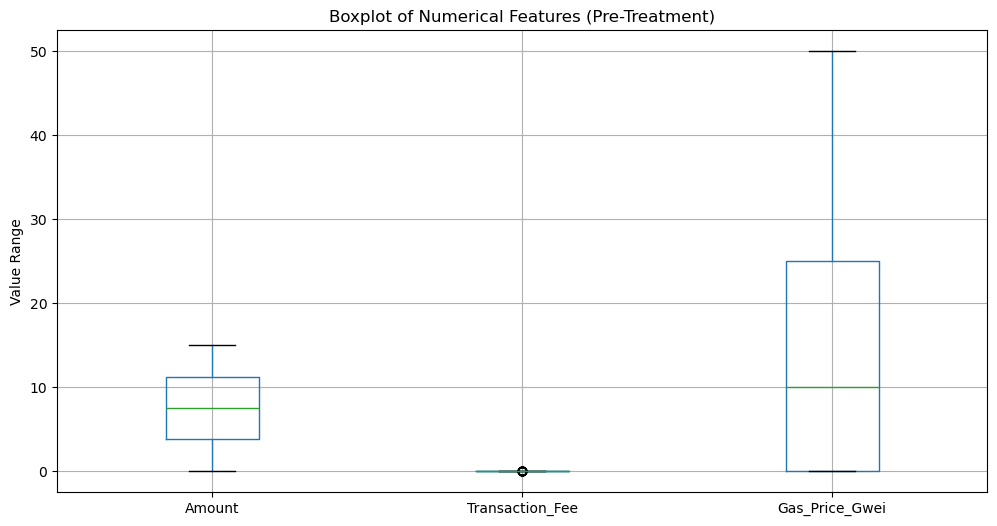

In [10]:
# Box plot for showing outliers
plt.figure(figsize=(12, 6))
crypto[numeric_cols].boxplot()
plt.title('Boxplot of Numerical Features (Pre-Treatment)')
plt.ylabel('Value Range')
plt.show()

In [11]:
#treating outliers
Q1, Q3 = crypto['Gas_Price_Gwei'].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
crypto['Gas_Price_Gwei'] = np.where(
    crypto['Gas_Price_Gwei'] > upper_limit,
    upper_limit,
    crypto['Gas_Price_Gwei'])

# Normalization and scaling

In [12]:
numeric_features = ['Amount', 'Transaction_Fee', 'Gas_Price_Gwei']
crypto_scaled = crypto.copy()
# Feature Scaling: Min-Max Normalization and Standardization
minmax_scaler = MinMaxScaler()
crypto_scaled[[f'{col}_MinMax' for col in numeric_features]] = minmax_scaler.fit_transform(crypto_scaled[numeric_features])
standard_scaler = StandardScaler()
crypto_scaled[[f'{col}_Standard' for col in numeric_features]] = standard_scaler.fit_transform(crypto_scaled[numeric_features])
crypto_scaled[[col for col in crypto_scaled.columns if 'MinMax' in col or 'Standard' in col]].head()

,Amount_MinMax,Transaction_Fee_MinMax,Gas_Price_Gwei_MinMax,Amount_Standard,Transaction_Fee_Standard,Gas_Price_Gwei_Standard
0,0.759652,0.052771,1.0,0.897203,-1.244894,2.220260
1,0.633455,0.033739,0.5,0.459332,-1.318160,0.696181
2,0.120584,0.190567,0.0,-1.320208,-0.714418,-0.827898
3,0.317033,0.700598,0.0,-0.638577,1.249056,-0.827898
4,0.822184,0.265905,1.0,1.114177,-0.424389,2.220260


### Showing the distribution of numerical features

<Figure size 1000x500 with 0 Axes>

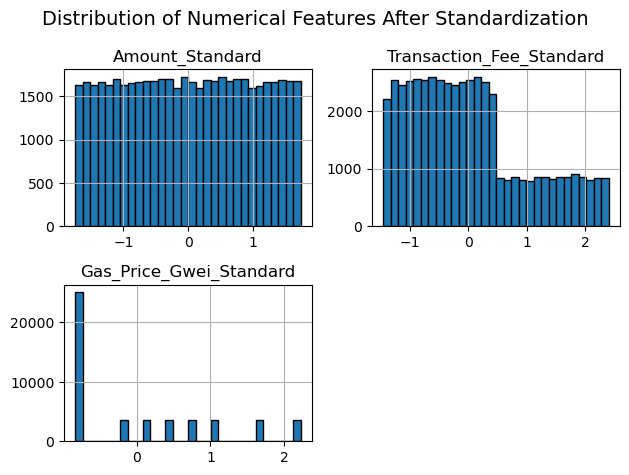

In [13]:
plt.figure(figsize=(10, 5))
crypto_scaled[[f'{col}_Standard' for col in numeric_features]].hist(bins=30, edgecolor='black')
plt.suptitle('Distribution of Numerical Features After Standardization', fontsize=14)
plt.tight_layout()
plt.show()

# Feature engineering

In [14]:
#accurate calculation of time intervals between transactions
crypto_scaled = crypto_scaled.sort_values(by=['Sender_Address', 'Timestamp'])
crypto_scaled['Time_Delta'] = crypto_scaled.groupby('Sender_Address')['Timestamp'].diff().dt.total_seconds()
crypto_scaled['Time_Delta'] = crypto_scaled['Time_Delta'].fillna(crypto_scaled['Time_Delta'].median())
#Identify high-activity senders possibly involved in scams or laundering
crypto_scaled['Sender_Tx_Count'] = crypto_scaled.groupby('Sender_Address')['Transaction_ID'].transform('count')
#Detect suspicious wallets that frequently receive funds
crypto_scaled['Receiver_Tx_Count'] = crypto_scaled.groupby('Receiver_Address')['Transaction_ID'].transform('count')

In [15]:
#Unusual fee ratios may signal urgent or fraudulent transactions
crypto_scaled['Fee_to_Amount_Ratio'] = crypto_scaled['Transaction_Fee'] / crypto_scaled['Amount']
crypto_scaled['Fee_to_Amount_Ratio'] = crypto_scaled['Fee_to_Amount_Ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)
crypto_scaled['Log_Fee_to_Amount'] = np.log1p(crypto_scaled['Fee_to_Amount_Ratio'])

In [16]:
#Encode categorical features for model compatibility
crypto_scaled['Mining_Pool_Code'] = crypto_scaled['Mining_Pool'].astype('category').cat.codes
crypto_scaled['Currency_Code'] = crypto_scaled['Currency'].astype('category').cat.codes

In [17]:
#Extract temporal features from timestamps
crypto_scaled['Hour'] = crypto_scaled['Timestamp'].dt.hour
crypto_scaled['DayOfWeek'] = crypto_scaled['Timestamp'].dt.dayofweek
crypto_scaled['Is_Weekend'] = crypto_scaled['DayOfWeek'].isin([5, 6]).astype(int)

In [18]:
# Preview key engineered features
crypto_scaled[['Amount', 'Transaction_Fee', 'Gas_Price_Gwei',
               'Sender_Tx_Count', 'Receiver_Tx_Count',
               'Fee_to_Amount_Ratio', 'Log_Fee_to_Amount',
               'Hour', 'Is_Weekend']].head()

,Amount,Transaction_Fee,Gas_Price_Gwei,Sender_Tx_Count,Receiver_Tx_Count,Fee_to_Amount_Ratio,Log_Fee_to_Amount,Hour,Is_Weekend
16272,4.762193,0.000072,50.0,1,1,0.000015,0.000015,9,0
21780,3.665944,0.000074,0.0,1,1,0.000020,0.000020,15,0
47207,3.225520,0.000124,0.0,1,1,0.000038,0.000038,1,0
2153,9.847970,0.000626,0.0,1,1,0.000064,0.000064,5,0
46484,0.903059,0.000398,25.0,1,1,0.000441,0.000441,14,0


In [19]:
# Simulate fraudulent behavior based on realistic patterns
crypto_scaled['is_fraud'] = np.where(
    (crypto_scaled['Fee_to_Amount_Ratio'] > crypto_scaled['Fee_to_Amount_Ratio'].quantile(0.99)) |
    (crypto_scaled['Amount'] > crypto_scaled['Amount'].quantile(0.995)) |
    ((crypto_scaled['Hour'] < 3) | (crypto_scaled['Hour'] > 22)), 
    1, 0)

# Redundancy elimination

In [20]:
constant_cols = [col for col in crypto_scaled.columns if crypto_scaled[col].nunique() == 1]
crypto_scaled.drop(columns=constant_cols, inplace=True)
print("Dropped constant columns:", constant_cols)

Dropped constant columns: ['Transaction_Type', 'Transaction_Status', 'Sender_Tx_Count', 'Receiver_Tx_Count']


In [21]:
crypto_scaled.drop(columns=['Time_Delta'], inplace=True, errors='ignore') # dropping the column

# Distribution analysis

In [22]:
crypto_scaled.describe().T # dataset description

,count,mean,std,min,25%,50%,75%,max
Amount,50000.0,7.519087e+00,4.321356,6.032080e-03,3.784158,7.514979,11.234608,14.999943
Transaction_Fee,50000.0,3.823800e-04,0.000257,1.002000e-05,0.000177,0.000340,0.000506,0.001000
Gas_Price_Gwei,50000.0,1.358030e+01,16.403516,0.000000e+00,0.000000,10.000000,25.000000,50.000000
Amount_MinMax,50000.0,5.010737e-01,0.288207,0.000000e+00,0.251977,0.500800,0.748876,1.000000
Transaction_Fee_MinMax,50000.0,3.761440e-01,0.259762,0.000000e+00,0.168995,0.333455,0.500907,1.000000
Gas_Price_Gwei_MinMax,50000.0,2.716060e-01,0.328070,0.000000e+00,0.000000,0.200000,0.500000,1.000000
Amount_Standard,50000.0,8.625989e-17,1.000010,-1.738605e+00,-0.864304,-0.000950,0.859813,1.731154
Transaction_Fee_Standard,50000.0,-2.717115e-16,1.000010,-1.448047e+00,-0.797464,-0.164342,0.480301,2.401668
Gas_Price_Gwei_Standard,50000.0,-1.982414e-17,1.000010,-8.278979e-01,-0.827898,-0.218266,0.696181,2.220260
Fee_to_Amount_Ratio,50000.0,1.873652e-04,0.001200,6.931197e-07,0.000023,0.000048,0.000102,0.080945


### Distribution of numeric column

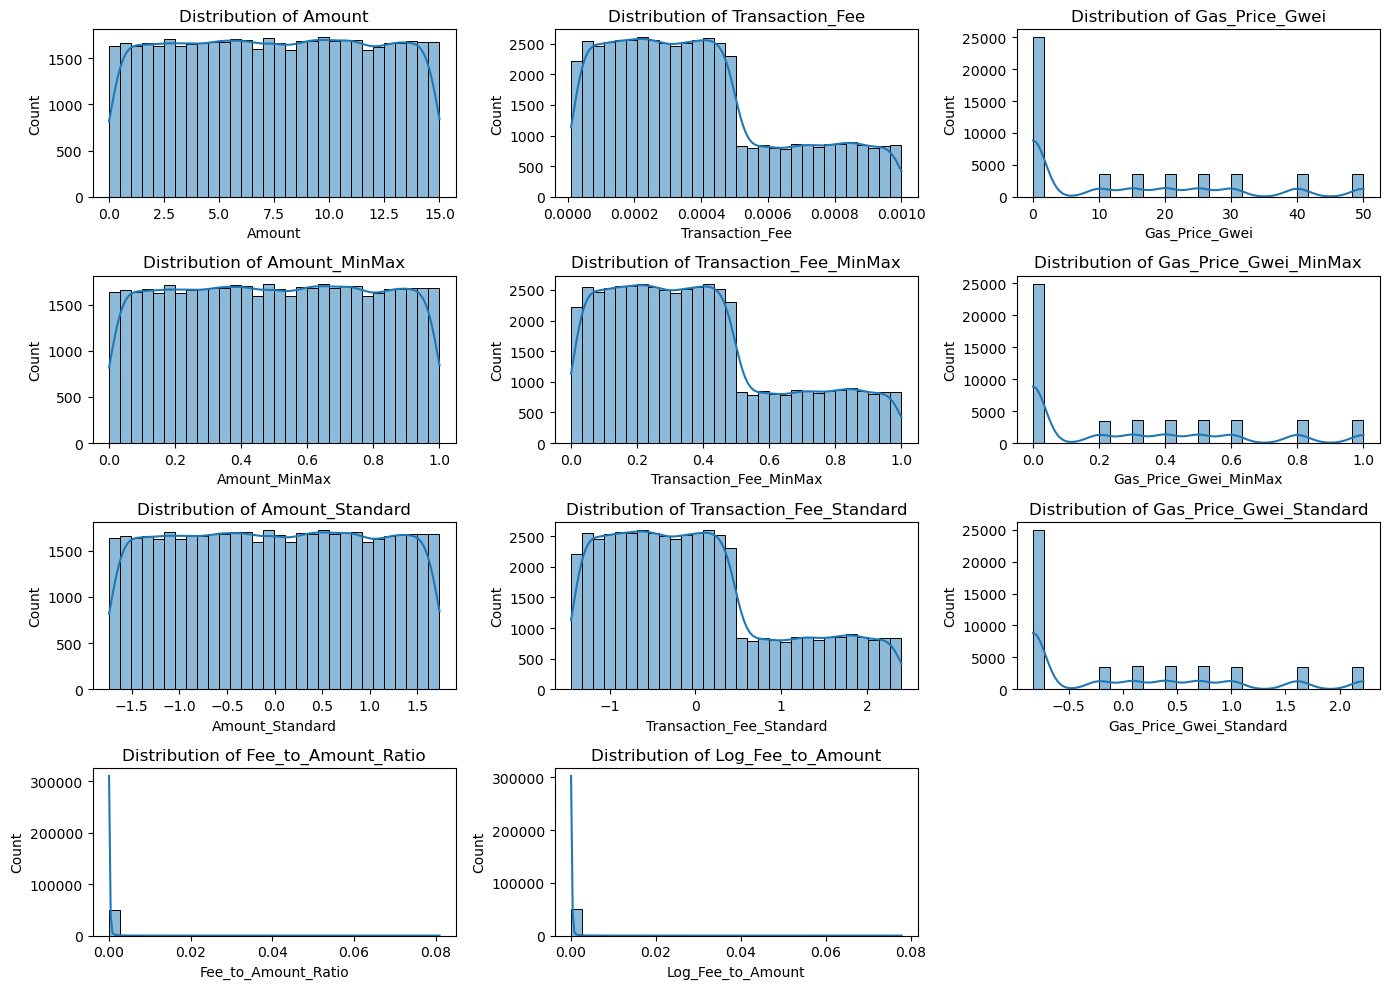

In [23]:
numeric_cols = crypto_scaled.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(14, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols) // 3 + 1, 3, i)
    sns.histplot(crypto_scaled[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Exploration of promising feature candidates

In [24]:
selector = VarianceThreshold(threshold=0.01)
selector.fit(crypto_scaled[numeric_cols])
high_var_features = numeric_cols[selector.get_support()]
print("High-variance features (potentially useful):")
print(high_var_features.tolist())

High-variance features (potentially useful):
['Amount', 'Gas_Price_Gwei', 'Amount_MinMax', 'Transaction_Fee_MinMax', 'Gas_Price_Gwei_MinMax', 'Amount_Standard', 'Transaction_Fee_Standard', 'Gas_Price_Gwei_Standard']


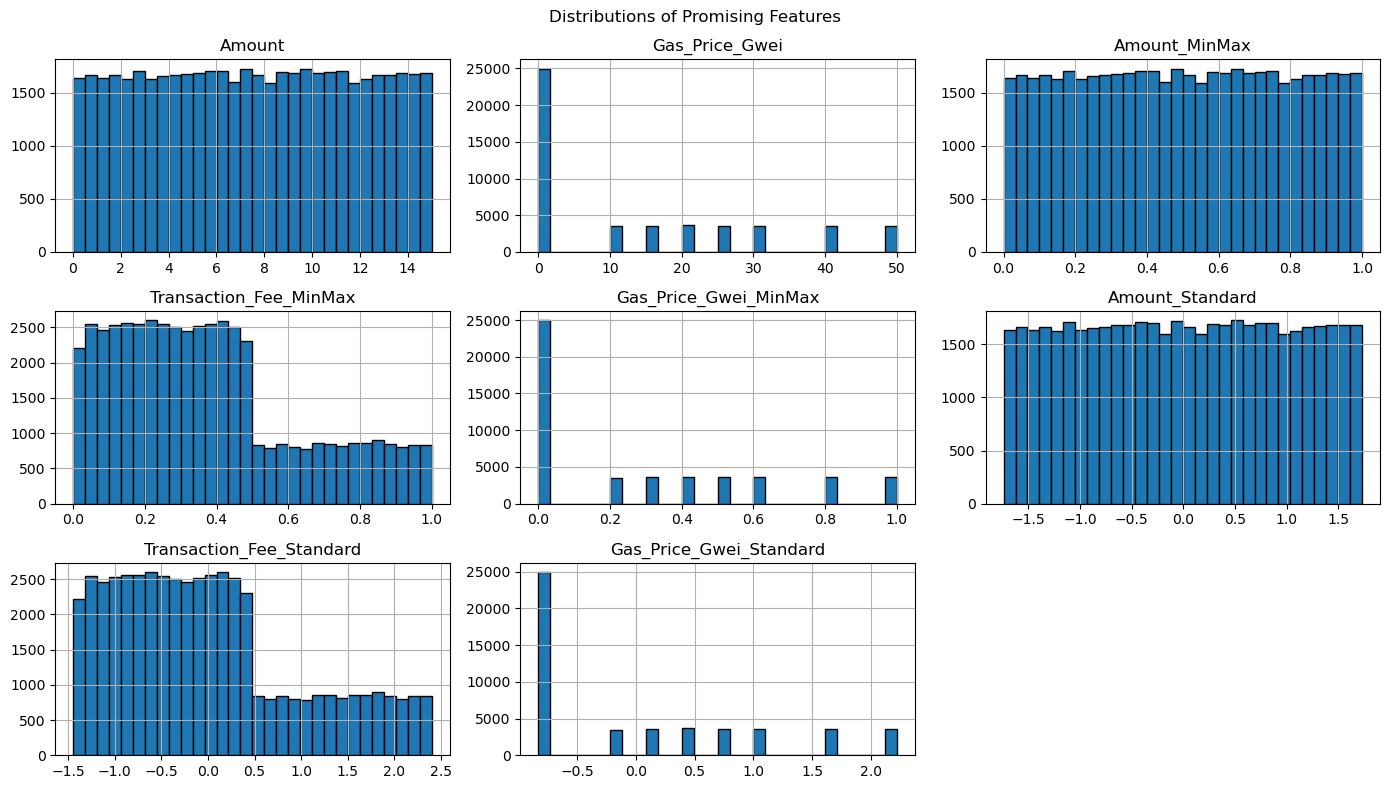

In [25]:
crypto_scaled[high_var_features].hist(figsize=(14, 8), bins=30, edgecolor='black')
plt.suptitle("Distributions of Promising Features")
plt.tight_layout()
plt.show()

# Correlation analysis

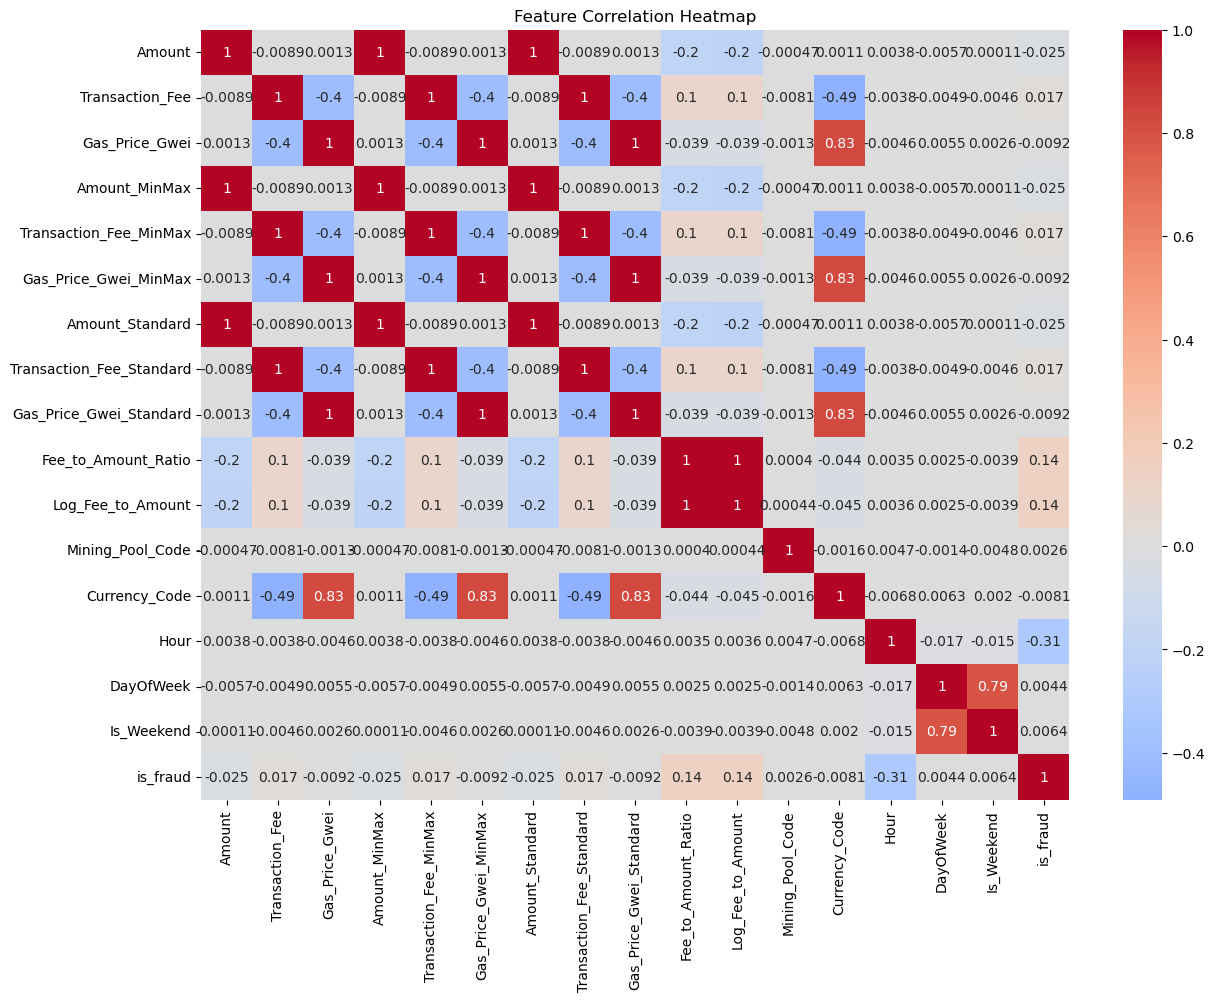

In [26]:
numeric_cols = crypto_scaled.select_dtypes(include=['float64', 'int32', 'int8']) # selected numerical variables
corr_matrix = numeric_cols.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True)
plt.title('Feature Correlation Heatmap')
plt.show()